<a href="https://colab.research.google.com/github/Damainx22/RGV-Business-Survival/blob/main/notebooks/08_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# Notebook 08: Machine Learning Model
# Purpose: Train Random Forest and XGBoost models
#          to predict SBA loan default risk.
#          Evaluate performance, analyze feature
#          importance, and save best model for
#          Streamlit deployment.
# ============================================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Standard imports
import os
import pandas as pd
import numpy as np

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb

# Explainability — SHAP shows why the model made each prediction
import shap

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import joblib

# Define folder paths
RAW = '/content/drive/MyDrive/rgv_business_survival/data/raw'
CLEANED = '/content/drive/MyDrive/rgv_business_survival/data/cleaned'
MERGED = '/content/drive/MyDrive/rgv_business_survival/data/merged'
MODELS = '/content/drive/MyDrive/rgv_business_survival/models'

# Create models folder if it doesn't exist
os.makedirs(MODELS, exist_ok=True)

# Load the feature matrix created in notebook 07
model_df = pd.read_csv(f'{MERGED}/model_features.csv')
print(f'Loaded: {model_df.shape[0]} rows, {model_df.shape[1]} columns')

Mounted at /content/drive
Loaded: 8064 rows, 608 columns


In [2]:
# ============================================
# Cell 2: Train/Test Split
# ============================================

# Separate features (X) from target variable (y)
# defaulted is what we're predicting — 1 = defaulted, 0 = survived
X = model_df.drop(columns=['defaulted'])
y = model_df['defaulted']

print(f'Features: {X.shape}')
print(f'Target distribution:')
print(y.value_counts())
print(f'Default rate: {y.mean()*100:.1f}%')

# Split into 80% training and 20% testing
# random_state=42 ensures reproducible results
# stratify=y ensures both splits have the same default rate
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'\nTraining set: {X_train.shape[0]} rows')
print(f'Test set: {X_test.shape[0]} rows')

Features: (8064, 607)
Target distribution:
defaulted
0    7099
1     965
Name: count, dtype: int64
Default rate: 12.0%

Training set: 6451 rows
Test set: 1613 rows


In [3]:
# ============================================
# Cell 3: Train Random Forest Model
# ============================================

# Compute class weights to handle imbalance (88% survived vs 12% defaulted)
# This tells the model to pay more attention to the minority class (defaulted)
classes = [0, 1]
weights = compute_class_weight('balanced', classes=np.array(classes), y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}
print(f'Class weights: {class_weight_dict}')

# Train Random Forest
# n_estimators=100 means 100 decision trees
# class_weight handles the imbalance
# random_state=42 for reproducibility
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weight_dict,
    random_state=42,
    n_jobs=-1  # use all CPU cores
)

rf_model.fit(X_train, y_train)
print('Random Forest trained!')

# Evaluate on test set
y_pred_rf = rf_model.predict(X_test)
print('\n=== Random Forest Results ===')
print(classification_report(y_test, y_pred_rf, target_names=['Survived', 'Defaulted']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]):.3f}')

Class weights: {0: np.float64(0.5679697129776369), 1: np.float64(4.178108808290156)}
Random Forest trained!

=== Random Forest Results ===
              precision    recall  f1-score   support

    Survived       0.91      0.99      0.95      1420
   Defaulted       0.87      0.31      0.45       193

    accuracy                           0.91      1613
   macro avg       0.89      0.65      0.70      1613
weighted avg       0.91      0.91      0.89      1613

ROC-AUC Score: 0.944


In [4]:
# ============================================
# Cell 4: Train XGBoost Model
# ============================================

# Calculate scale_pos_weight for XGBoost's way of handling imbalance
# = number of negative cases / number of positive cases
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

# Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)
print('XGBoost trained!')

# Evaluate
y_pred_xgb = xgb_model.predict(X_test)
print('\n=== XGBoost Results ===')
print(classification_report(y_test, y_pred_xgb, target_names=['Survived', 'Defaulted']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]):.3f}')

scale_pos_weight: 7.36
XGBoost trained!

=== XGBoost Results ===
              precision    recall  f1-score   support

    Survived       0.97      0.96      0.97      1420
   Defaulted       0.72      0.81      0.76       193

    accuracy                           0.94      1613
   macro avg       0.85      0.88      0.86      1613
weighted avg       0.94      0.94      0.94      1613

ROC-AUC Score: 0.964


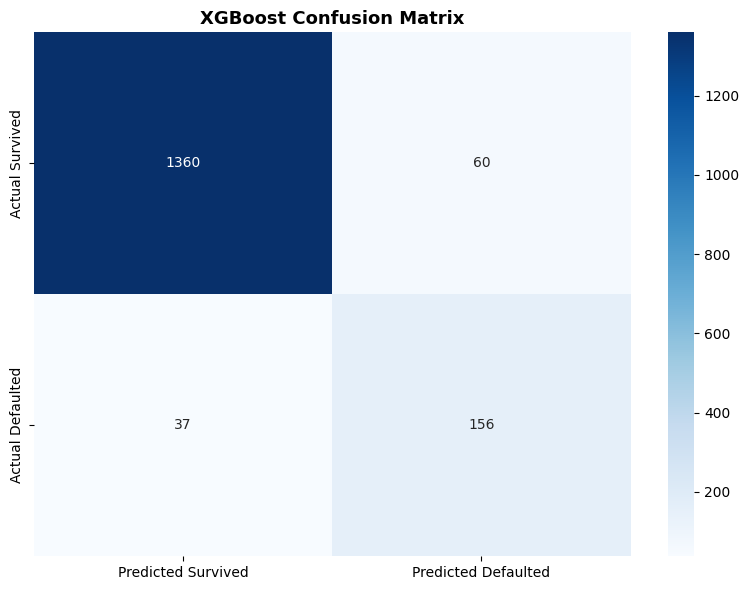

True Positives (caught defaults): 156
False Negatives (missed defaults): 37
False Positives (wrong default prediction): 60
True Negatives (correct survival): 1360


In [5]:
# ============================================
# Cell 5: Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Survived', 'Predicted Defaulted'],
            yticklabels=['Actual Survived', 'Actual Defaulted'])
ax.set_title('XGBoost Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODELS}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'True Positives (caught defaults): {cm[1][1]}')
print(f'False Negatives (missed defaults): {cm[1][0]}')
print(f'False Positives (wrong default prediction): {cm[0][1]}')
print(f'True Negatives (correct survival): {cm[0][0]}')

/tmp/ipykernel_9560/1301762934.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature',


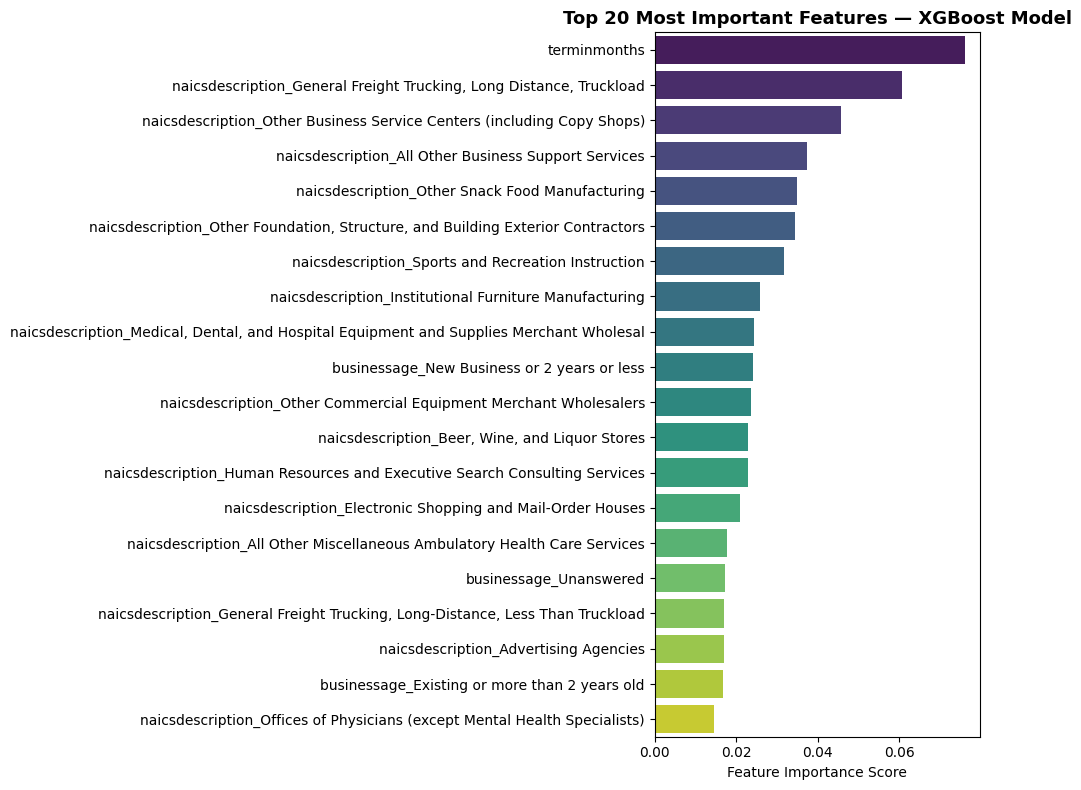

                                                                                     feature  importance
4                                                                               terminmonths    0.075928
231                      naicsdescription_General Freight Trucking, Long Distance, Truckload    0.060564
380                   naicsdescription_Other Business Service Centers (including Copy Shops)    0.045674
21                                      naicsdescription_All Other Business Support Services    0.037235
423                                          naicsdescription_Other Snack Food Manufacturing    0.035010
396          naicsdescription_Other Foundation, Structure, and Building Exterior Contractors    0.034502
537                                       naicsdescription_Sports and Recreation Instruction    0.031598
270                                   naicsdescription_Institutional Furniture Manufacturing    0.025857
315  naicsdescription_Medical, Dental, and Hospital Equ

In [6]:
# ============================================
# Cell 6: Feature Importance
# ============================================

# Get top 20 most important features
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=importance_df, x='importance', y='feature',
            palette='viridis', ax=ax)
ax.set_title('Top 20 Most Important Features — XGBoost Model',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{MODELS}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(importance_df.to_string())

In [7]:
# ============================================
# Cell 7: Save the Model
# ============================================

# Save XGBoost model — this is what the Streamlit app will load
joblib.dump(xgb_model, f'{MODELS}/xgb_model.pkl')

# Save the feature column names — needed to match input format in the app
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, f'{MODELS}/feature_columns.pkl')

print('Model saved!')
print('Feature columns saved!')
print(os.listdir(MODELS))

Model saved!
Feature columns saved!
['confusion_matrix.png', 'feature_importance.png', 'xgb_model.pkl', 'feature_columns.pkl']


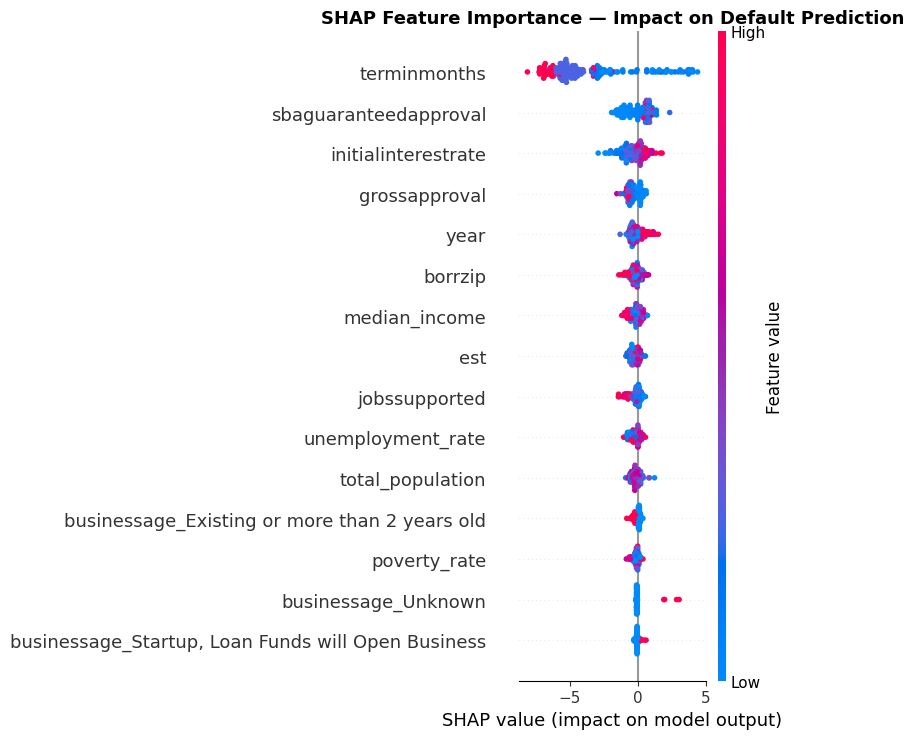

SHAP plot saved!


In [8]:
# ============================================
# Cell 8: SHAP Explainability
# Addresses professor comment about using SHAP
# to explain why the model made each prediction
# ============================================

# Create SHAP explainer using the trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values on test set (use sample for speed)
X_test_sample = X_test.iloc[:200]
shap_values = explainer.shap_values(X_test_sample)

# Summary plot — shows which features impact predictions most
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample,
                  max_display=15,
                  show=False)
plt.title('SHAP Feature Importance — Impact on Default Prediction',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODELS}/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP plot saved!')